In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    "../data/processed/moj_sales_2020_2025_merged.csv.gz",
    compression="gzip"
)

df.head()

C:\Users\huawel\AppData\Local\Temp\ipykernel_20944\3237444784.py:1: DtypeWarning: Columns (0: property_type, 1: plan_number, 2: plot_number, 3: price_raw, 4: area_raw) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,region_raw,city,city_district,reference_number,date_gregorian_raw,date_hijri,property_classification,property_type,plan_number,plot_number,...,price_per_m2_reported,source_file,year,quarter,price,area,transaction_date,region_raw_stripped,region_en,price_per_m2_calculated
0,منطقة مكة المكرمه,الطائف,الطائف/ طيبة,9470090.0,2020/01/01,1441/05/06,سكني,NaN,NaN,NaN,...,NaN,MOJ-Sales-2020-Q1.csv,2020,1,300000.0,835.50,2020-01-01,منطقة مكة المكرمه,Makkah,359.066427
1,منطقة مكة المكرمه,الطائف,الطائف/ الجودية,9472004.0,2020/01/01,1441/05/06,سكني,NaN,NaN,NaN,...,NaN,MOJ-Sales-2020-Q1.csv,2020,1,54000.0,900.00,2020-01-01,منطقة مكة المكرمه,Makkah,60.000000
2,منطقة مكة المكرمه,الطائف,الطائف/ حي البوادي,9471841.0,2020/01/01,1441/05/06,سكني,NaN,NaN,NaN,...,NaN,MOJ-Sales-2020-Q1.csv,2020,1,75000.0,677.50,2020-01-01,منطقة مكة المكرمه,Makkah,110.701107
3,منطقة مكة المكرمه,الطائف,الطائف/ الكدى,9473011.0,2020/01/01,1441/05/06,سكني,NaN,NaN,NaN,...,NaN,MOJ-Sales-2020-Q1.csv,2020,1,100000.0,665.14,2020-01-01,منطقة مكة المكرمه,Makkah,150.344288
4,منطقة مكة المكرمه,الطائف,الطائف/ الكدى,9472659.0,2020/01/01,1441/05/06,سكني,NaN,NaN,NaN,...,NaN,MOJ-Sales-2020-Q1.csv,2020,1,100000.0,665.14,2020-01-01,منطقة مكة المكرمه,Makkah,150.344288


In [3]:
df.shape

(1407132, 23)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1407132 entries, 0 to 1407131
Data columns (total 23 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   region_raw               1407120 non-null  str    
 1   city                     1407120 non-null  str    
 2   city_district            1407120 non-null  str    
 3   reference_number         1407120 non-null  float64
 4   date_gregorian_raw       1407120 non-null  str    
 5   date_hijri               1363029 non-null  str    
 6   property_classification  1407120 non-null  str    
 7   property_type            131447 non-null   str    
 8   plan_number              44091 non-null    str    
 9   plot_number              44091 non-null    str    
 10  n_properties             1407120 non-null  float64
 11  price_raw                1407120 non-null  object 
 12  area_raw                 1407120 non-null  object 
 13  price_per_m2_reported    44091 non-null    float64
 1

In [5]:
df.describe(include="all")

c:\Users\huawel\Saudi-Property-Transaction-Price-Prediction\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,region_raw,city,city_district,reference_number,date_gregorian_raw,date_hijri,property_classification,property_type,plan_number,plot_number,...,price_per_m2_reported,source_file,year,quarter,price,area,transaction_date,region_raw_stripped,region_en,price_per_m2_calculated
count,1407120,1407120,1407120,1.407120e+06,1407120,1363029,1407120,131447,44091,44091,...,44091.000000,1407132,1.407132e+06,1.407132e+06,1.407120e+06,1.407120e+06,1407120,1407120,1407120,1.407120e+06
unique,16,174,17488,NaN,2189,2099,6,11,4886,12046,...,NaN,24,NaN,NaN,NaN,NaN,2189,16,13,NaN
top,منطقة الرياض,الرياض,الرياض/الخير,NaN,2020/06/30,1441/11/09,سكني,قطعة أرض,مخطط/أخرى,قطعة بدون,...,NaN,MOJ-Sales-2021-Q1.csv.gz,NaN,NaN,NaN,NaN,2020-06-30,منطقة الرياض,Riyadh,NaN
freq,477347,329927,32044,NaN,4717,4717,1201675,104947,9300,2002,...,NaN,92963,NaN,NaN,NaN,NaN,4717,477347,477347,NaN
mean,NaN,NaN,NaN,1.871751e+07,NaN,NaN,NaN,NaN,NaN,NaN,...,1708.866406,NaN,2.022321e+03,2.456640e+00,1.044396e+06,6.195507e+03,NaN,NaN,NaN,inf
std,NaN,NaN,NaN,6.811903e+06,NaN,NaN,NaN,NaN,NaN,NaN,...,2645.478105,NaN,1.735726e+00,1.162134e+00,5.110937e+07,9.238497e+04,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,8.595804e+06,NaN,NaN,NaN,NaN,NaN,NaN,...,0.010000,NaN,2.020000e+03,1.000000e+00,5.000000e+03,0.000000e+00,NaN,NaN,NaN,1.851852e-03
25%,NaN,NaN,NaN,1.227388e+07,NaN,NaN,NaN,NaN,NaN,NaN,...,166.666600,NaN,2.021000e+03,1.000000e+00,1.110000e+05,3.750000e+02,NaN,NaN,NaN,1.893939e+02
50%,NaN,NaN,NaN,1.772255e+07,NaN,NaN,NaN,NaN,NaN,NaN,...,720.351300,NaN,2.022000e+03,2.000000e+00,3.500000e+05,5.755000e+02,NaN,NaN,NaN,6.593407e+02
75%,NaN,NaN,NaN,2.406275e+07,NaN,NaN,NaN,NaN,NaN,NaN,...,2339.541300,NaN,2.024000e+03,4.000000e+00,7.500000e+05,7.500000e+02,NaN,NaN,NaN,1.860000e+03


In [6]:
missing = df.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

plan_number                1363041
price_per_m2_reported      1363041
plot_number                1363041
property_type              1275685
date_hijri                   44103
city_district                   12
city                            12
region_raw                      12
reference_number                12
property_classification         12
n_properties                    12
date_gregorian_raw              12
price_raw                       12
area_raw                        12
price                           12
area                            12
transaction_date                12
region_raw_stripped             12
region_en                       12
price_per_m2_calculated         12
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.columns.tolist()

['region_raw',
 'city',
 'city_district',
 'reference_number',
 'date_gregorian_raw',
 'date_hijri',
 'property_classification',
 'property_type',
 'plan_number',
 'plot_number',
 'n_properties',
 'price_raw',
 'area_raw',
 'price_per_m2_reported',
 'source_file',
 'year',
 'quarter',
 'price',
 'area',
 'transaction_date',
 'region_raw_stripped',
 'region_en',
 'price_per_m2_calculated']

In [9]:
df[['price', 'area', 'n_properties']].describe()

,price,area,n_properties
count,1.407120e+06,1.407120e+06,1.407120e+06
mean,1.044396e+06,6.195507e+03,1.036547e+00
std,5.110937e+07,9.238497e+04,7.424670e-01
min,5.000000e+03,0.000000e+00,1.000000e+00
25%,1.110000e+05,3.750000e+02,1.000000e+00
50%,3.500000e+05,5.755000e+02,1.000000e+00
75%,7.500000e+05,7.500000e+02,1.000000e+00
max,3.183750e+10,2.400724e+07,3.260000e+02


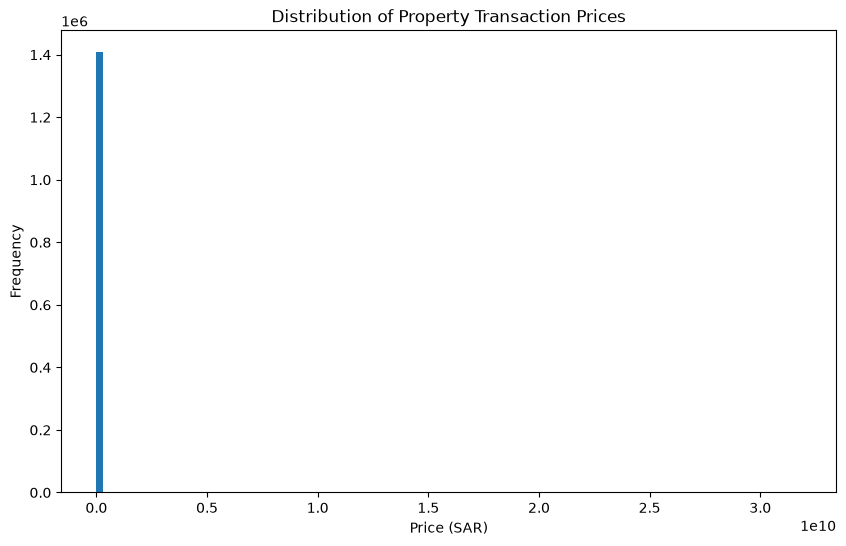

In [10]:
plt.figure(figsize=(10, 6))

plt.hist(df['price'].dropna(), bins=100)

plt.xlabel('Price (SAR)')
plt.ylabel('Frequency')
plt.title('Distribution of Property Transaction Prices')

plt.show()

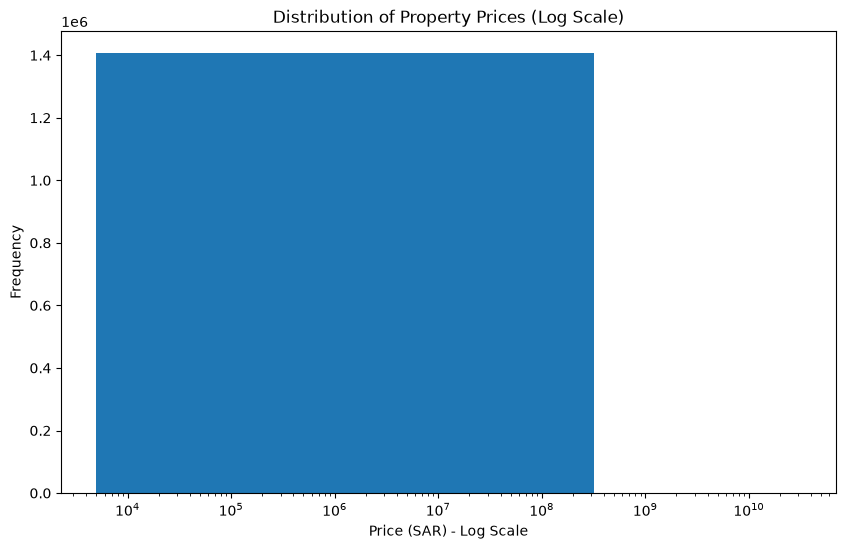

In [11]:
plt.figure(figsize=(10, 6))

plt.hist(df['price'].dropna(), bins=100)
plt.xscale('log')

plt.xlabel('Price (SAR) - Log Scale')
plt.ylabel('Frequency')
plt.title('Distribution of Property Prices (Log Scale)')

plt.show()

In [12]:
(df['area'] == 0).sum()

np.int64(1)

In [13]:
(df['price'] <= 0).sum()

np.int64(0)

In [15]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['price'] < lower_bound) |
    (df['price'] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of outliers:", len(outliers))
print("Percentage of outliers:", len(outliers) / len(df) * 100)

Q1: 111000.0
Q3: 750000.0
IQR: 639000.0
Lower Bound: -847500.0
Upper Bound: 1708500.0
Number of outliers: 110439
Percentage of outliers: 7.8485174098805235


In [16]:
region_price = (
    df.groupby('region_en')['price']
      .agg(['count', 'mean', 'median', 'min', 'max'])
      .sort_values('median', ascending=False)
)

region_price

,count,mean,median,min,max
region_en,,,,,
Makkah,277286,1.150052e+06,500000.0,5000.0,1.037820e+09
Riyadh,477347,1.683289e+06,495000.0,5000.0,3.183750e+10
Eastern Province,195199,9.395481e+05,419600.0,5000.0,2.891766e+09
Madinah,62935,7.182527e+05,400000.0,5000.0,7.600000e+08
Tabuk,29076,4.397394e+05,280000.0,5000.0,1.567672e+08
Jazan,31500,3.280546e+05,200000.0,5000.0,5.107458e+07
Asir,69167,4.168530e+05,200000.0,5000.0,5.008601e+08
Qassim,120875,3.201549e+05,141075.0,5000.0,4.984200e+08
Al Baha,8970,1.866238e+05,100000.0,5000.0,2.550438e+07


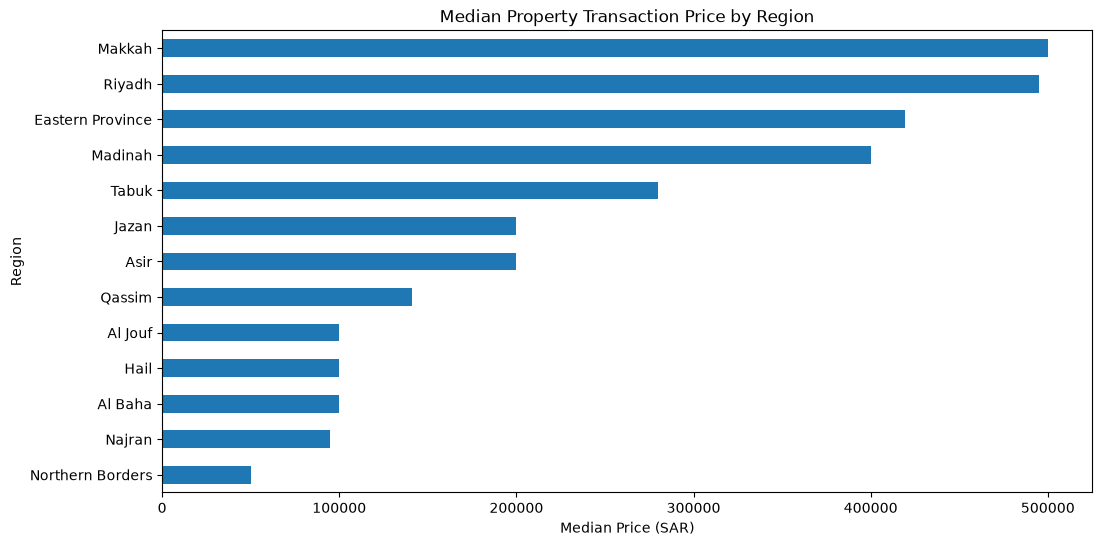

In [17]:
plt.figure(figsize=(12, 6))

region_price['median'].sort_values().plot(kind='barh')

plt.xlabel('Median Price (SAR)')
plt.ylabel('Region')
plt.title('Median Property Transaction Price by Region')

plt.show()

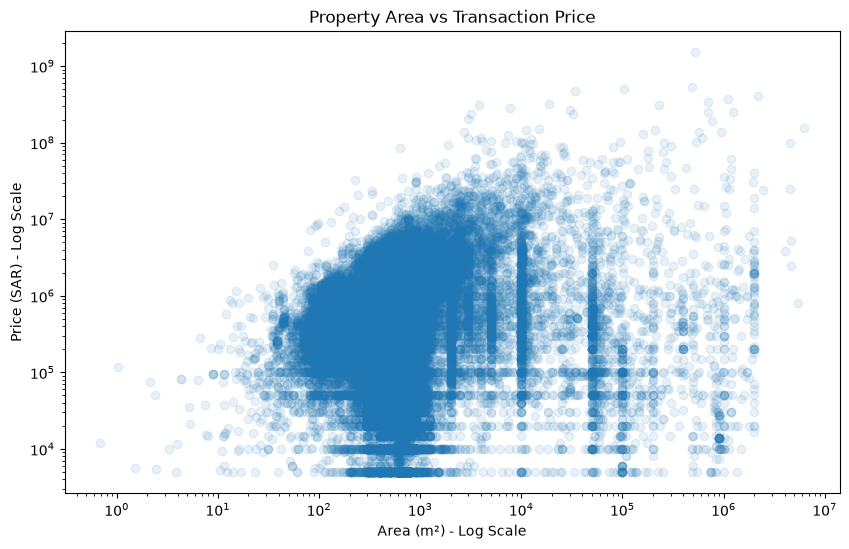

In [18]:
sample = df[['area', 'price']].dropna()

# نستبعد المساحة صفر لأننا سنستخدم log scale
sample = sample[sample['area'] > 0]

# نأخذ عينة 100,000 صف حتى يكون الرسم أسرع وأوضح
sample = sample.sample(100000, random_state=42)

plt.figure(figsize=(10, 6))

plt.scatter(
    sample['area'],
    sample['price'],
    alpha=0.1
)

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Area (m²) - Log Scale')
plt.ylabel('Price (SAR) - Log Scale')
plt.title('Property Area vs Transaction Price')

plt.show()

In [19]:
correlation = df[['area', 'price']].corr()

correlation


,area,price
area,1.000000,0.044273
price,0.044273,1.000000


In [20]:
property_price = (
    df.groupby('property_classification')['price']
      .agg(['count', 'mean', 'median'])
      .sort_values('median', ascending=False)
)

property_price


,count,mean,median
property_classification,,,
صناعي,74,7.612466e+06,3300000.0
سكني تجاري,2,5.450000e+05,545000.0
تجاري,149767,3.420926e+06,520000.0
زراعي,55601,1.149126e+06,350000.0
سكني,1201675,7.429555e+05,340000.0
أخرى,1,5.000000e+04,50000.0


In [21]:
year_price = (
    df.groupby('year')['price']
      .agg(['count', 'mean', 'median'])
)

year_price

,count,mean,median
year,,,
2020,276811,1.247194e+06,230000.0
2021,281883,7.193312e+05,290000.0
2022,213754,1.020131e+06,380000.0
2023,183788,1.106152e+06,400000.0
2024,249328,1.127893e+06,470000.0
2025,201556,1.086624e+06,445852.5


In [22]:
top_cities = df['city'].value_counts().head(15)

top_cities


city
الرياض             329927
جده                163666
بريده               62425
مكة المكرمة         53298
المدينة المنورة     52211
حائل                38152
الدمام              38001
الهفوف              34306
الخبر               32756
حفر الباطن          29958
الطائف              29387
الخرج               26887
تبوك                23452
عرعر                17751
ابها                17634
Name: count, dtype: int64

Median Price by Top Cities


In [23]:
city_price = (
    df.groupby('city')['price']
      .agg(['count', 'mean', 'median'])
      .sort_values('count', ascending=False)
      .head(15)
)

city_price

,count,mean,median
city,,,
الرياض,329927,2.187431e+06,650000.0
جده,163666,1.373765e+06,606538.0
بريده,62425,4.201212e+05,180000.0
مكة المكرمة,53298,1.332654e+06,520000.0
المدينة المنورة,52211,8.065786e+05,490000.0
حائل,38152,3.116411e+05,164000.0
الدمام,38001,1.825614e+06,864621.0
الهفوف,34306,5.461283e+05,360000.0
الخبر,32756,1.742356e+06,740000.0


In [24]:
top_5_cities = df['city'].value_counts().head(5).index

city_year_price = (
    df[df['city'].isin(top_5_cities)]
    .groupby(['year', 'city'])['price']
    .median()
    .unstack()
)

city_year_price

city,الرياض,المدينة المنورة,بريده,جده,مكة المكرمة
year,,,,,
2020,433660.0,399813.5,150000.0,470000.0,455000.0
2021,550000.0,440500.0,150000.0,594736.0,467902.0
2022,780000.0,450000.0,197320.0,800000.0,460000.0
2023,720000.0,533200.0,180000.0,640965.0,530000.0
2024,730000.0,550000.0,207532.0,600000.0,600000.0
2025,770000.0,537600.0,257700.0,610000.0,720000.0


In [25]:
df['property_type'].value_counts(dropna=False)

property_type
NaN           1275685
قطعة أرض       104947
شقة             21322
أرض زراعية       3641
بيت               918
معرض/محل          231
فيلا              231
مرفق               58
عمارة              52
مركز تجاري         24
إستراحة            22
قصر                 1
Name: count, dtype: int64

Property type information is available for only a small subset of transactions. Among transactions with available property type information, land plots and apartments are the most common categories.

In [27]:
property_type_price = (
    df.dropna(subset=['property_type'])
      .groupby('property_type')['price']
      .agg(['count', 'mean', 'median', 'min', 'max'])
      .sort_values('median', ascending=False)
)

property_type_price

,count,mean,median,min,max
property_type,,,,,
قصر,1,4.696720e+07,46967200.00,46967200.0,4.696720e+07
مركز تجاري,24,1.255101e+07,3783122.50,200000.0,1.865687e+08
مرفق,58,7.407221e+06,1430000.00,15000.0,7.779200e+07
فيلا,231,1.300517e+06,903501.00,5000.0,1.285000e+07
شقة,21322,6.435533e+05,561193.87,5000.0,4.146121e+07
إستراحة,22,6.194682e+05,380000.00,100000.0,2.640000e+06
عمارة,52,8.413061e+05,372756.50,20000.0,1.350000e+07
قطعة أرض,104947,1.178361e+06,303200.00,5000.0,2.657190e+09
أرض زراعية,3641,1.055510e+06,300000.00,5000.0,6.000000e+07


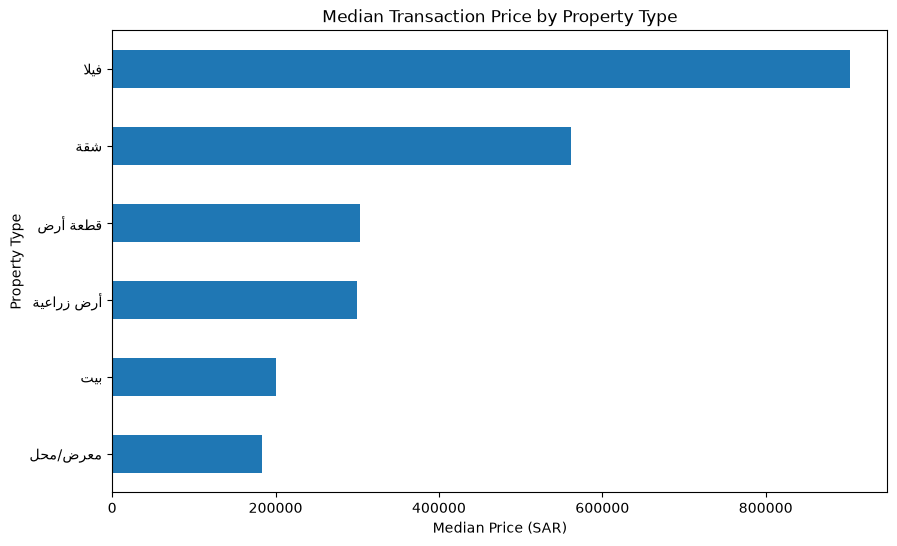

In [28]:
property_type_filtered = property_type_price[
    property_type_price['count'] >= 100
]

plt.figure(figsize=(10, 6))

property_type_filtered['median'].sort_values().plot(kind='barh')

plt.xlabel('Median Price (SAR)')
plt.ylabel('Property Type')
plt.title('Median Transaction Price by Property Type')

plt.show()

In [29]:
property_type_year = (
    df.dropna(subset=['property_type'])
      .groupby(['year', 'property_type'])['price']
      .median()
      .unstack()
)

property_type_year

property_type,أرض زراعية,إستراحة,بيت,شقة,عمارة,فيلا,قصر,قطعة أرض,مرفق,مركز تجاري,معرض/محل
year,,,,,,,,,,,
2023,300000.0,380000.0,200000.0,561193.87,372756.5,903501.0,46967200.0,303200.0,1430000.0,3783122.5,183000.0


Property type information is available only for transactions recorded in 2023. Therefore, property-type trends over time cannot be reliably analyzed across the full 2020–2025 period.

In [31]:
Q1_price = df['price'].quantile(0.25)
Q3_price = df['price'].quantile(0.75)

IQR_price = Q3_price - Q1_price

lower_price = Q1_price - 1.5 * IQR_price
upper_price = Q3_price + 1.5 * IQR_price

price_outliers = df[
    (df['price'] < lower_price) |
    (df['price'] > upper_price)
]

print("Q1:", Q1_price)
print("Q3:", Q3_price)
print("IQR:", IQR_price)
print("Lower Bound:", lower_price)
print("Upper Bound:", upper_price)
print("Number of outliers:", len(price_outliers))
print("Percentage:", len(price_outliers) / len(df) * 100)

Q1: 111000.0
Q3: 750000.0
IQR: 639000.0
Lower Bound: -847500.0
Upper Bound: 1708500.0
Number of outliers: 110439
Percentage: 7.8485174098805235


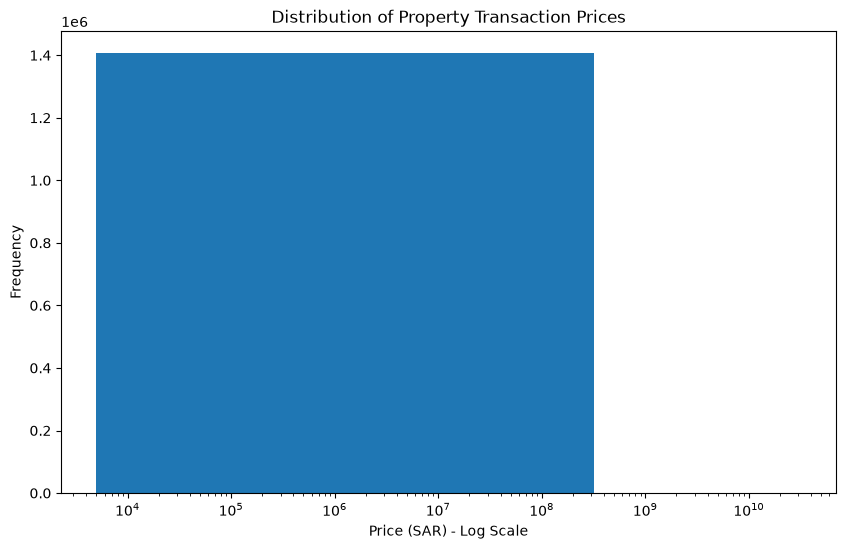

In [32]:
plt.figure(figsize=(10, 6))

plt.hist(df['price'], bins=100)

plt.xscale('log')

plt.xlabel('Price (SAR) - Log Scale')
plt.ylabel('Frequency')
plt.title('Distribution of Property Transaction Prices')

plt.show()

In [33]:
Q1_area = df['area'].quantile(0.25)
Q3_area = df['area'].quantile(0.75)

IQR_area = Q3_area - Q1_area

lower_area = Q1_area - 1.5 * IQR_area
upper_area = Q3_area + 1.5 * IQR_area

area_outliers = df[
    (df['area'] < lower_area) |
    (df['area'] > upper_area)
]

print("Q1:", Q1_area)
print("Q3:", Q3_area)
print("IQR:", IQR_area)
print("Lower Bound:", lower_area)
print("Upper Bound:", upper_area)
print("Number of outliers:", len(area_outliers))
print("Percentage:", len(area_outliers) / len(df) * 100)

Q1: 375.0
Q3: 750.0
IQR: 375.0
Lower Bound: -187.5
Upper Bound: 1312.5
Number of outliers: 102002
Percentage: 7.248929027269652


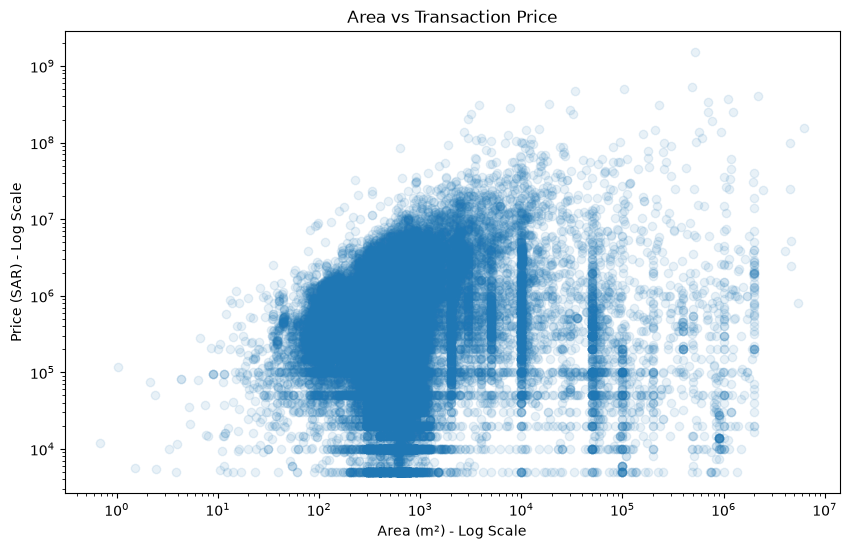

In [34]:
sample = df[['area', 'price']].dropna()

sample = sample[sample['area'] > 0]

sample = sample.sample(100000, random_state=42)

plt.figure(figsize=(10, 6))

plt.scatter(
    sample['area'],
    sample['price'],
    alpha=0.1
)

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Area (m²) - Log Scale')
plt.ylabel('Price (SAR) - Log Scale')
plt.title('Area vs Transaction Price')

plt.show()